In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### importing the analytics dataset

In [24]:
df = pd.read_csv("../data/cleaned/analytics-dataset.csv")

In [25]:
df


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,total_value,delivery_time_days,order_month,order_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,38.71,8.0,2017-10,2017
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,38.71,8.0,2017-10,2017
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,38.71,8.0,2017-10,2017
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,13.0,2018-07,2018
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840.0,guariba,SP,179.12,9.0,2018-08,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117599,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,40.0,10.0,40.0,17602.0,tupa,SP,195.00,22.0,2018-02,2018
117600,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,32.0,90.0,22.0,8290.0,sao paulo,SP,271.01,24.0,2017-08,2017
117601,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,20.0,20.0,37175.0,ilicinea,MG,220.58,17.0,2018-01,2018
117602,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,20.0,20.0,37175.0,ilicinea,MG,220.58,17.0,2018-01,2018


##  This a Olist Ecommerce business analysis


## Revenue trend Over time

In [32]:
monthly_revenue = (
    df.groupby("order_month")["total_value"]
      .sum()
      .reset_index()
)

In [33]:
type(monthly_revenue)

pandas.DataFrame

In [35]:
monthly_revenue["order_month"] = monthly_revenue["order_month"].astype(str)

## plot 

In [36]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

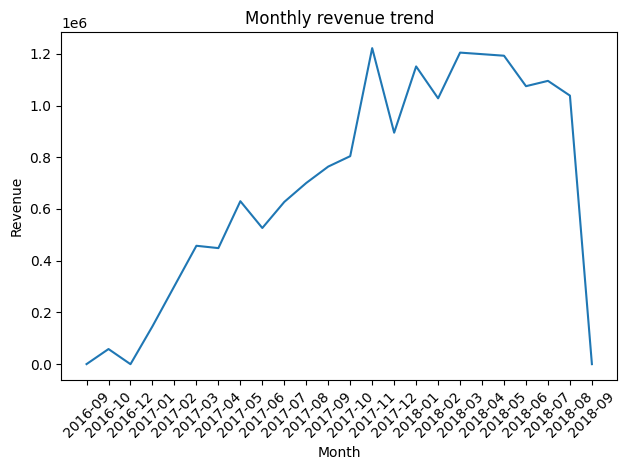

In [42]:
plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["total_value"]
)

plt.title("Monthly revenue trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Insights -

Revenue peaked during October and declined during August

The overall trend suggests growth.

Possible causes may include changes in customer demand.

## Top product categories -

In [58]:
top_products = (
    df.groupby("product_category_name")["total_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [59]:
type(top_products)

pandas.Series

In [60]:
top_products

product_category_name
beleza_saude              1486023.75
relogios_presentes        1357478.82
cama_mesa_banho           1310284.13
esporte_lazer             1198524.35
informatica_acessorios    1095456.98
moveis_decoracao           946593.12
utilidades_domesticas      820851.24
cool_stuff                 750150.02
automotivo                 712442.08
ferramentas_jardim         623851.98
Name: total_value, dtype: float64

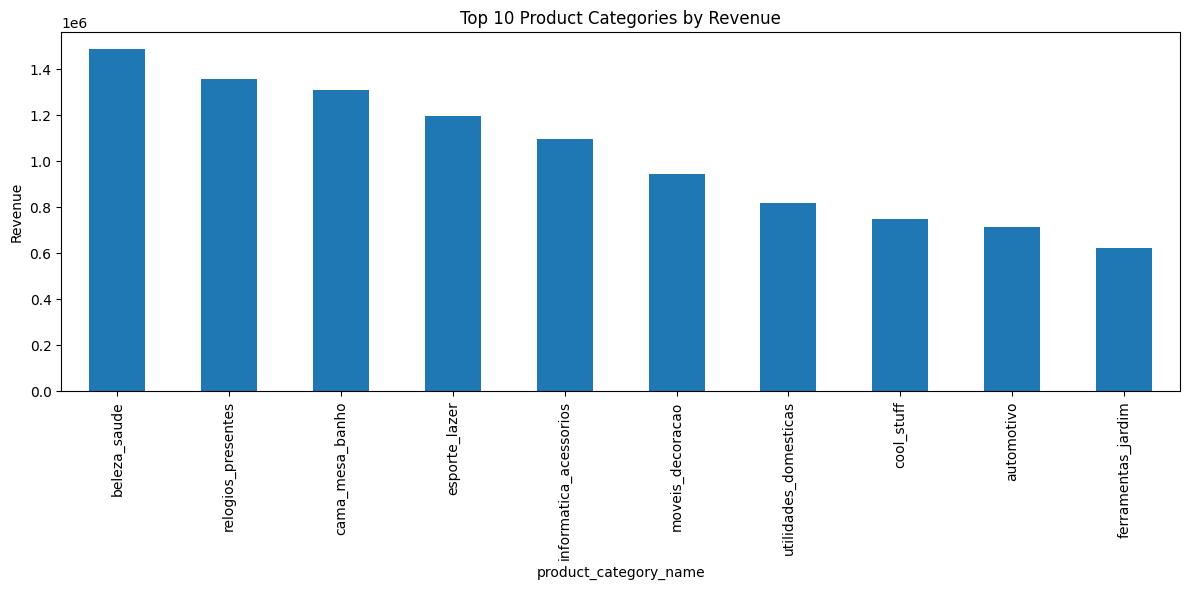

In [61]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [62]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state', 'total_value',
       'delivery_time_days', 'order_month', 'order_year'],
      dtype='str')

## Top customer states - 


In [66]:
top_customer_states = (
    df.groupby("customer_state")["total_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [67]:
top_customer_states

customer_state
SP    6201661.39
RJ    2236978.11
MG    1920938.14
RS     929350.22
PR     828526.16
BA     647949.82
SC     630431.81
DF     365186.90
GO     365071.75
ES     335290.50
Name: total_value, dtype: float64

## plot-

In [68]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

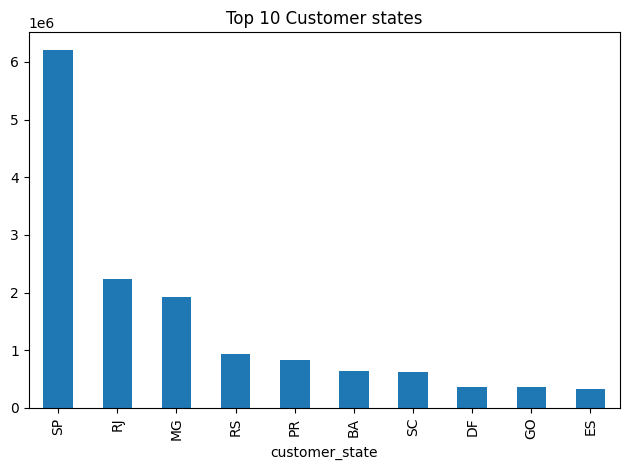

In [69]:
top_customer_states.plot(kind='bar')
plt.title("Top 10 Customer states")
plt.tight_layout()
plt.show()

## Top sellers-

In [71]:
top_sellers = (
    
    df.groupby("seller_id")["total_value"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_sellers

seller_id
53243585a1d6dc2643021fd1853d8905    258882.28
4869f7a5dfa277a7dca6462dcf3b52b2    258625.52
7c67e1448b00f6e969d365cea6b010ab    252549.32
4a3ca9315b744ce9f8e9374361493884    250635.29
fa1c13f2614d7b5c4749cbc52fecda94    214454.82
da8622b14eb17ae2831f4ac5b9dab84a    195751.05
7e93a43ef30c4f03f38b393420bc753a    189475.90
1025f0e2d44d7041d6cf58b6550e0bfa    176845.92
7a67c85e85bb2ce8582c35f2203ad736    172013.25
955fee9216a65b617aa5c0531780ce60    163183.53
Name: total_value, dtype: float64

## plot-

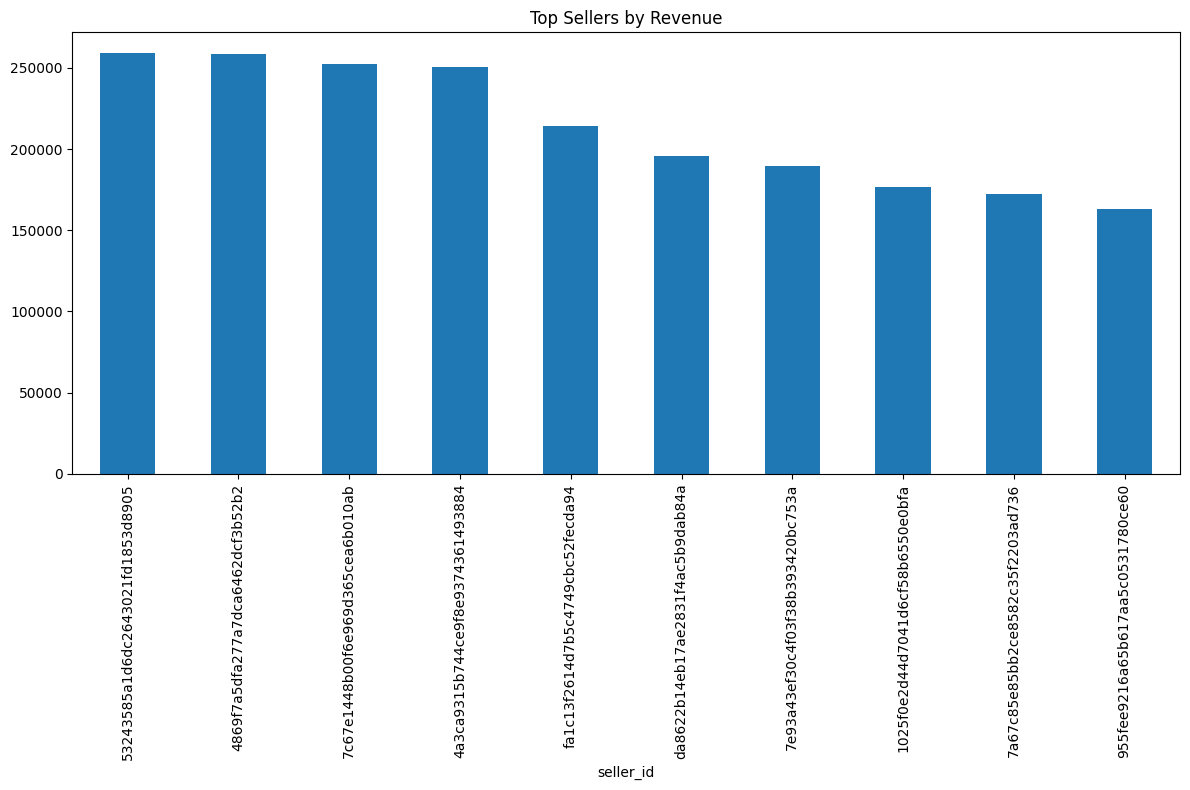

In [79]:
plt.figure(figsize=(12,8))

top_sellers.plot(kind="bar")

plt.title("Top Sellers by Revenue")

plt.tight_layout()
plt.show()

## Delivery time related analysis-

In [81]:
df["delivery_time_days"]

0          8.0
1          8.0
2          8.0
3         13.0
4          9.0
          ... 
117599    22.0
117600    24.0
117601    17.0
117602    17.0
117603     7.0
Name: delivery_time_days, Length: 117604, dtype: float64

In [83]:
df["delivery_time_days"].describe()

count    115037.000000
mean         12.019237
std           9.461440
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time_days, dtype: float64

In [86]:
df[df["delivery_time_days"] > 25]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,total_value,delivery_time_days,order_month,order_year
31,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12 00:00:00,a25d5f94840d3c6a1a49f271ed83f4ec,21715,...,16.0,12.0,22.0,9220.0,santo andre,SP,125.43,28.0,2018-02,2018
36,ecab90c9933c58908d3d6add7c6f5ae3,761df82feda9778854c6dafdaeb567e4,delivered,2018-02-25 13:50:30,2018-02-25 14:47:35,2018-02-26 22:28:50,2018-03-27 23:29:14,2018-04-13 00:00:00,1428917cd397d4f9ac0fde76dd6f2266,69317,...,20.0,20.0,20.0,81350.0,curitiba,PR,63.34,30.0,2018-02,2018
42,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,delivered,2018-02-17 15:59:46,2018-02-17 16:15:34,2018-02-20 23:03:56,2018-03-20 00:59:25,2018-03-20 00:00:00,92fd8aa5948e20c43a014c44c025c5e1,77480,...,90.0,20.0,20.0,4782.0,sao paulo,SP,106.95,30.0,2018-02,2018
48,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21 00:00:00,3e4fd73f1e86b135b9b121d6abbe9597,19400,...,38.0,34.0,34.0,89165.0,rio do sul,SC,356.12,33.0,2017-11,2017
118,6a0a8bfbbe700284feb0845d95e0867f,68451b39b1314302c08c65a29f1140fc,delivered,2017-11-22 11:32:22,2017-11-22 11:46:50,2017-11-27 13:39:35,2017-12-28 19:43:00,2017-12-11 00:00:00,781ae350edb16842380e81d7c7feb431,20740,...,45.0,15.0,35.0,14940.0,ibitinga,SP,101.74,36.0,2017-11,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117407,4cf09d9e5ebbe0f91ddd7bf9aae891cd,07b6b4fe5fefb948fc76b6d2bdba77d8,delivered,2018-07-19 08:37:26,2018-07-21 03:25:17,2018-07-23 15:31:00,2018-08-21 01:12:45,2018-08-10 00:00:00,862f461bf6a1f5dbf360fb9cf8814757,41630,...,25.0,12.0,38.0,80310.0,curitiba,PR,390.90,32.0,2018-07,2018
117474,bdc11cf6acd11917b9ea3d91b95e1395,675292c8870ca23721c9c66a588dd982,delivered,2018-03-28 23:09:36,2018-03-28 23:26:49,2018-03-29 19:59:58,2018-04-26 12:54:39,2018-04-25 00:00:00,94cffd1e5129cf8537e1d034e553c259,24913,...,20.0,8.0,21.0,9015.0,santo andre,SP,65.22,28.0,2018-03,2018
117575,e6cc57f923c4dab2222b8c9aa8742eea,2f4a42f9bb4b9a8cd402fa549df5c7fd,delivered,2018-02-07 12:09:45,2018-02-07 12:31:13,2018-02-21 23:38:05,2018-03-05 18:56:39,2018-05-11 00:00:00,312823a3a38d7ad3046d8ba7122f93a8,70648,...,20.0,16.0,17.0,17209.0,jau,SP,128.54,26.0,2018-02,2018
117581,38e9133ce29f6bbe35aed9c3863dce01,ad312389a098ceff46ce92c4595c06d0,delivered,2017-10-12 20:54:11,2017-10-14 03:28:24,2017-10-17 17:04:42,2017-11-21 17:06:59,2017-10-31 00:00:00,a3983b8b6b679c9f645e6ef9517ac98d,14802,...,16.0,7.0,11.0,2310.0,sao paulo,SP,48.75,39.0,2017-10,2017


In [101]:
df[df["delivery_time_days"] > 100 ][[
    "order_id","customer_state","delivery_time_days","order_purchase_timestamp","order_delivered_customer_date"]
    ]

,order_id,customer_state,delivery_time_days,order_purchase_timestamp,order_delivered_customer_date
1927,a4efaffc506a395c9cea7402b078c1e5,CE,110.0,2018-01-17 10:50:09,2018-05-07 19:25:33
3623,8b7fd198ad184563c231653673e75a7f,SP,105.0,2017-11-14 10:04:27,2018-02-27 18:05:08
3762,4f39a94d6e474819d898d6df7d394996,GO,143.0,2017-04-28 16:28:03,2017-09-19 13:54:18
3763,4f39a94d6e474819d898d6df7d394996,GO,143.0,2017-04-28 16:28:03,2017-09-19 13:54:18
5442,b31c7dea63bb08f8cdd1ec32514ccf0b,RJ,132.0,2017-09-26 18:35:35,2018-02-05 21:25:43
...,...,...,...,...,...
102179,ed8e9faf1b75f43ee027103957135663,SP,173.0,2017-11-29 15:10:14,2018-05-21 18:22:18
105246,285ab9426d6982034523a855f55a885e,SE,194.0,2017-03-08 22:47:40,2017-09-19 14:00:04
108963,29c3b79aace1b72a82b1232bf494e16f,MG,133.0,2017-12-16 10:04:35,2018-04-28 15:51:50
112488,17cc6728043d53cc948551dfbf0a338b,CE,142.0,2017-11-25 12:14:38,2018-04-16 23:26:51


In [102]:
extreme_delays = df[df["delivery_time_days"] > 100]

extreme_delays.shape

(71, 37)

In [103]:
extreme_delays["customer_state"].value_counts().head(10)

customer_state
SP    18
RJ    10
BA    10
GO     5
CE     4
ES     4
RS     3
MG     3
PA     2
PI     2
Name: count, dtype: int64

In [104]:
extreme_delays["seller_id"].value_counts().head(10)

seller_id
cac4c8e7b1ca6252d8f20b2fc1a2e4af    4
2a1348e9addc1af5aaa619b1a3679d6b    3
82e0a475a88cc9595229d8029273f045    2
da8622b14eb17ae2831f4ac5b9dab84a    2
1f50f920176fa81dab994f9023523100    2
fe2032dab1a61af8794248c8196565c9    2
cca3071e3e9bb7d12640c9fbe2301306    2
e81e1f9c3e762e620f3fb60a51499e16    2
9c0e69c7bf2619675bbadf47b43f655a    2
3d871de0142ce09b7081e2b9d1733cb1    1
Name: count, dtype: int64

In [105]:
extreme_delays["product_category_name"].value_counts().head(10)

product_category_name
moveis_decoracao         7
utilidades_domesticas    7
esporte_lazer            6
cama_mesa_banho          5
automotivo               5
ferramentas_jardim       4
unknown                  3
bebes                    3
relogios_presentes       3
telefonia                3
Name: count, dtype: int64

## Insight related to delivery: 
A total of 71 orders took more than 100 days to be delivered.

These delays were concentrated among specific states, sellers, and product categories, suggesting operational issues rather than random variation.